# Spin splitting of collinear magnets and altermagnets
In a collinear magnet the spin-up and spin-down bands are split, and the natural measure of
that order is how far apart the two spin channels are pushed, and at which energy. Pairing
the bands of the two channels by index, every k-point and band $n$ has a splitting
$\Delta_n(k)=E^\uparrow_n(k)-E^\downarrow_n(k)$ at the mean energy of the pair. In a
ferromagnet the splitting is the same everywhere, while an altermagnet carries no net
magnetization and its splitting changes sign across the Brillouin zone.
`h.get_spin_splitting_density()` broadens every pair into a smooth density, the typical
splitting at each energy, and `h.get_spin_splitting_vs_energy()` keeps the largest
$|\Delta|$ found in each energy bin over the whole Brillouin zone, so that its maximum bounds
the splitting anywhere in the zone, rather than along one cut chosen by hand. Both require
spin to be a good quantum number.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import specialhamiltonian

### Energy-resolved spin splitting
We compare a ferromagnet, a square lattice with an exchange field, with a d-wave altermagnet
on the same lattice. The ferromagnet is split by twice its exchange field at every energy of
the band, while the splitting of the altermagnet is largest in the middle of the band and
vanishes at its edges.

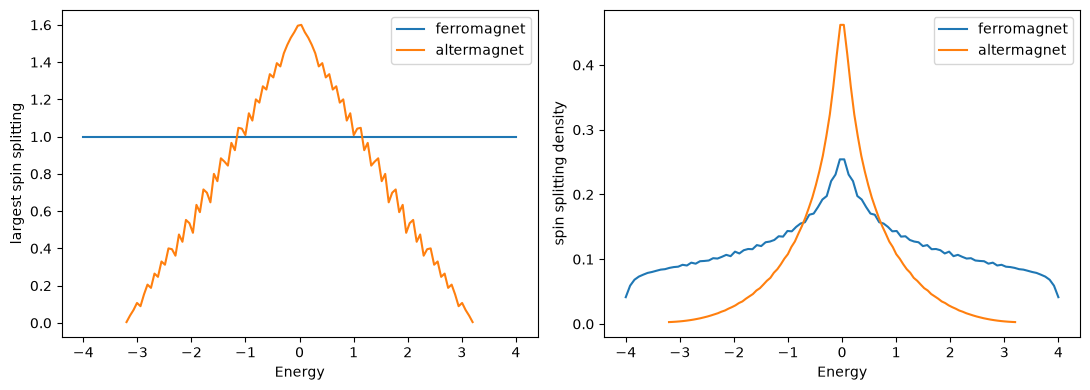

In [2]:
hf = geometry.square_lattice().get_hamiltonian() # square lattice
hf.add_exchange([0.,0.,0.5]) # ferromagnet
ha = specialhamiltonian.square_altermagnet(am=0.4) # d-wave altermagnet

fig,axs = plt.subplots(1,2,figsize=(11,4))
for (h,label) in [(hf,"ferromagnet"),(ha,"altermagnet")]:
    (es,ds) = h.get_spin_splitting_vs_energy(nk=60,nbins=100) # largest splitting per bin
    (xs,ys) = h.get_spin_splitting_density(nk=60,delta=1e-1,energies=es) # typical splitting
    axs[0].plot(es,ds,label=label)
    axs[1].plot(xs,ys,label=label)
axs[0].set_ylabel("largest spin splitting") ; axs[1].set_ylabel("spin splitting density")
for ax in axs:
    ax.set_xlabel("Energy") ; ax.legend()
plt.tight_layout()
plt.show()

### Spin splitting over the Brillouin zone
The difference between the two magnets is clearest in reciprocal space. On the left, the
spin-resolved Fermi surface, `h.get_fermi_surface(operator="sz")`: the ferromagnet has two
concentric pockets of opposite spin, while the altermagnet has two pockets of the same size
rotated by 90 degrees with respect to each other. On the right, the splitting $\Delta(k)$ of
the band over the Brillouin zone, obtained by keeping one spin channel at a time with
`h.remove_spin()`: uniform for the ferromagnet, and with the $d$-wave sign pattern of
$\cos k_x-\cos k_y$ for the altermagnet, positive along one axis and negative along the
other.

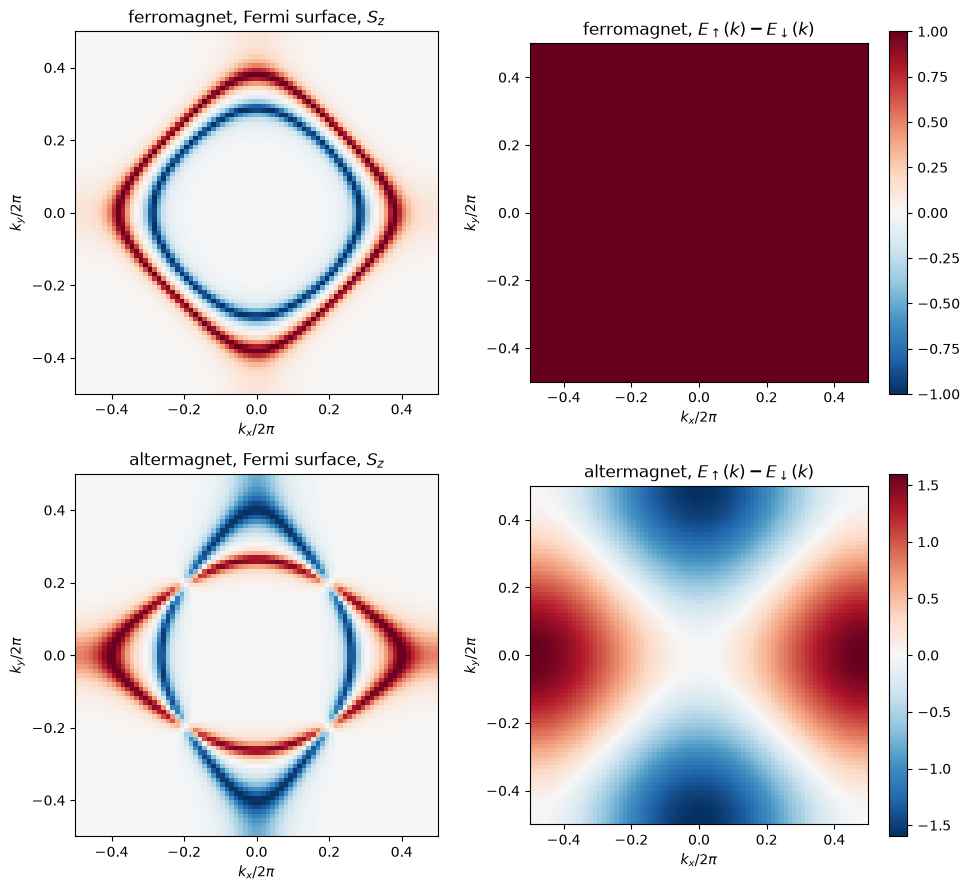

In [3]:
nk = 80
kxs = np.linspace(-0.5,0.5,nk) # one Brillouin zone, in reduced coordinates
fig,axs = plt.subplots(2,2,figsize=(10,9))
for (i,(h,label)) in enumerate([(hf,"ferromagnet"),(ha,"altermagnet")]):
    (kx,ky,fs) = h.get_fermi_surface(e=1.,nk=nk,nsuper=0.5,delta=0.2,
            operator="sz",write=False) # spin-resolved Fermi surface
    fmax = np.max(np.abs(fs))
    axs[i,0].imshow(fs.reshape(nk,nk).T,origin="lower",cmap="RdBu_r",vmin=-fmax,vmax=fmax,
            extent=[-0.5,0.5,-0.5,0.5])
    axs[i,0].set_title(label+", Fermi surface, $S_z$")
    hup = h.copy() ; hup.remove_spin(channel="up") # spin-up channel
    hdn = h.copy() ; hdn.remove_spin(channel="dn") # spin-down channel
    fup = hup.get_hk_gen() ; fdn = hdn.get_hk_gen() # Bloch Hamiltonians
    split = np.array([[fup([k1,k2,0.])[0,0].real - fdn([k1,k2,0.])[0,0].real
                       for k2 in kxs] for k1 in kxs]) # E_up(k) - E_dn(k)
    smax = np.max(np.abs(split))
    im = axs[i,1].imshow(split.T,origin="lower",cmap="RdBu_r",vmin=-smax,vmax=smax,
            extent=[-0.5,0.5,-0.5,0.5])
    axs[i,1].set_title(label+r", $E_\uparrow(k)-E_\downarrow(k)$")
    plt.colorbar(im,ax=axs[i,1])
for ax in axs.flatten():
    ax.set_xlabel(r"$k_x/2\pi$") ; ax.set_ylabel(r"$k_y/2\pi$")
plt.tight_layout()
plt.show()